# Chapter 31: Deep Learning for Tabular Data

**Does a neural model that is worse on its own lower the blend's error, and does that survive as the tree model gets more data?**

The decision to build a neural model is usually made on its standalone score, and then it loses. Measuring what it adds to the blend, with the weight chosen on development rows, is the comparison the chapter asks for.

*Constructed data; the sizes of these effects are properties of this generator and the small network, not a competition result.*

## The experiment

Six constructed regression datasets with eight standard-normal features. The target has smooth terms, two sharp steps and an interaction, plus noise of standard deviation 0.5. A histogram gradient boosting regressor, whose tree size (4 or 8 leaves) and number of boosting rounds are chosen on 600 separate development rows, and a one-hidden-layer network (32 units, scaled inputs and target, fixed settings) are fitted on the training rows (the control). The blend weight on the network is chosen on the same 600 development rows, or on only 60 of them, and everything is scored by mean squared error on 5,000 untouched rows. Equal averaging is also shown.

In [1]:
import warnings

import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

from kaggle_companion.activities._common import clean

SEED = 31
REPLICATES = 6          # independent constructed datasets; every estimate is their mean
N_DEV, N_SMALL_DEV, N_NEW = 600, 60, 5000
GRID = np.linspace(0, 1, 21)   # candidate blend weights on the neural model: 0 is the GBM alone, 1 the network alone


def truth(X):
    """Smooth terms (easy for a network) plus two sharp steps and an interaction (easy for trees)."""
    smooth = np.sin(1.5 * X[:, 0]) + 0.6 * X[:, 1] ** 2 + 0.5 * X[:, 2] + 0.4 * np.tanh(2 * X[:, 3])
    steps = 1.2 * ((X[:, 4] > 0.3) & (X[:, 5] > -0.2)) + 0.8 * (X[:, 6] > 0.8)
    return smooth + steps


def generate(n, rng):
    X = rng.normal(size=(n, 8))
    return X, truth(X) + rng.normal(0, 0.5, n)


def mse(pred, y):
    return float(np.mean((pred - y) ** 2))


def best_weight(p_net, p_gbm, y):
    """The weight on the network that minimizes squared error on these rows."""
    return float(GRID[int(np.argmin([mse(w * p_net + (1 - w) * p_gbm, y) for w in GRID]))])


def credible_trees(X, y, X_dev, y_dev):
    """A credible tree baseline: tree size and the number of boosting rounds are chosen on the development rows."""
    best = None
    for leaves in (4, 8):
        trial = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.08, max_leaf_nodes=leaves, min_samples_leaf=5,
                                              random_state=0).fit(X, y)
        errors = [mse(p, y_dev) for p in trial.staged_predict(X_dev)]     # development error after each boosting round
        rounds = int(np.argmin(errors)) + 1
        if best is None or errors[rounds - 1] < best[0]:
            best = (errors[rounds - 1], leaves, rounds)
    return HistGradientBoostingRegressor(max_iter=best[2], learning_rate=0.08, max_leaf_nodes=best[1], min_samples_leaf=5,
                                         random_state=0).fit(X, y)


def one_replicate(train_rows, seed):
    rng = np.random.default_rng(seed)
    X, y = generate(train_rows, rng)
    X_dev, y_dev = generate(N_DEV, rng)         # development rows: tune the trees and choose the blend weight here
    X_new, y_new = generate(N_NEW, rng)         # untouched rows: score here only
    gbm = credible_trees(X, y, X_dev, y_dev)
    scaler, mean, sd = StandardScaler().fit(X), y.mean(), y.std()      # the network needs scaled inputs and target
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")        # a small network may stop at the iteration cap; that is part of the trial
        net = MLPRegressor(hidden_layer_sizes=(32,), alpha=0.1, learning_rate_init=0.003, max_iter=300,
                           random_state=seed).fit(scaler.transform(X), (y - mean) / sd)
    predict_net = lambda Z: net.predict(scaler.transform(Z)) * sd + mean
    g_dev, n_dev, g_new, n_new = gbm.predict(X_dev), predict_net(X_dev), gbm.predict(X_new), predict_net(X_new)

    w = best_weight(n_dev, g_dev, y_dev)                                           # weight from 600 development rows
    w_small = best_weight(n_dev[:N_SMALL_DEV], g_dev[:N_SMALL_DEV], y_dev[:N_SMALL_DEV])   # weight from only 60 rows
    blend = lambda weight: weight * n_new + (1 - weight) * g_new
    return {"gbm": mse(g_new, y_new), "net": mse(n_new, y_new), "equal": mse(blend(0.5), y_new),
            "dev_weight": mse(blend(w), y_new), "small_dev_weight": mse(blend(w_small), y_new),
            "weight": w, "small_weight": w_small,
            "residual_corr": float(np.corrcoef(g_new - y_new, n_new - y_new)[0, 1])}


def run(train_rows):
    reps = [one_replicate(train_rows, SEED * 100 + i) for i in range(REPLICATES)]
    mean = lambda key: float(np.mean([r[key] for r in reps]))
    keys = ("gbm", "net", "equal", "dev_weight", "small_dev_weight")
    return clean({
        "train_rows": train_rows,
        **{k: mean(k) for k in keys},
        "weight": mean("weight"), "small_weight": mean("small_weight"),
        "small_weight_range": [min(r["small_weight"] for r in reps), max(r["small_weight"] for r in reps)],
        "residual_corr": mean("residual_corr"),
        "per_replicate_gain": {k: [r["gbm"] - r[k] for r in reps] for k in ("equal", "dev_weight", "small_dev_weight")},
        "replicates": REPLICATES, "development_rows": N_DEV, "small_development_rows": N_SMALL_DEV, "new_rows": N_NEW,
    })


## Measure it across the control

The control is **training rows for both models**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch31 import explain

VALUES = [150, 400, 1000, 3000]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                               150    400   1000   3000
Trees alone                  0.649  0.464  0.354  0.296
Network alone                0.953  0.682  0.501  0.391
Equal blend                  0.644  0.476  0.366  0.309
Blend, weight from 600 rows  0.609  0.446  0.345  0.293
Blend, weight from 60 rows   0.620  0.452  0.349  0.296
Residual correlation          0.63   0.68   0.73   0.81


## Look at it

The figure shows the default setting, training rows for both models = 400.

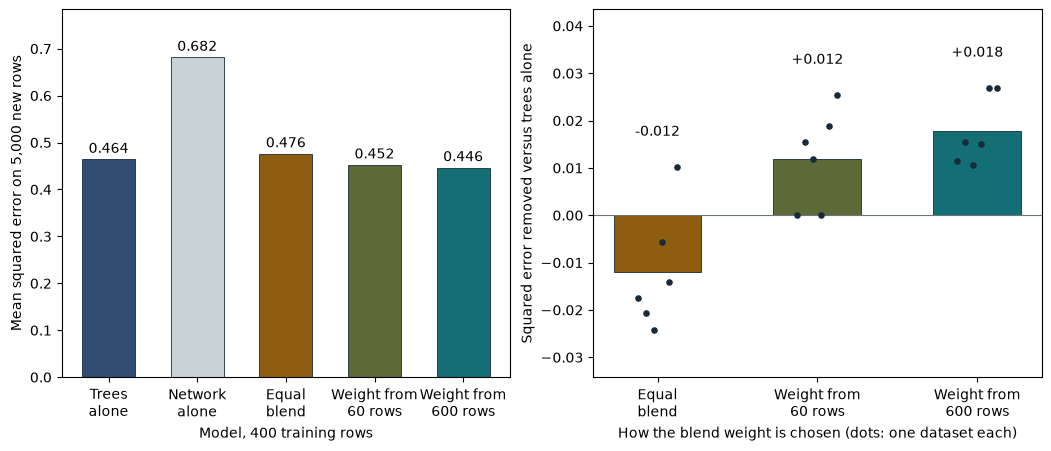

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch31 import draw, NCOLS, HEIGHT

DEFAULT = 400
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With 400 training rows the trees score 0.464 and the network 0.682, so the network is worse on its own. A blend with the weight chosen on 600 development rows scores 0.446, and 0.464 - 0.446 = 0.018 is the error it removes versus the trees. The chosen weight on the network averages 0.19; equal averaging scores 0.476. Choosing the weight on 60 rows scores 0.452 with weights between 0.00 and 0.35 across datasets. The two models' errors correlate at 0.68.

- Trees alone: 0.464; network alone: 0.682 (mean squared error on new rows).
- Blend, weight from 600 rows: 0.464 - 0.446 = +0.018 versus trees.
- Equal blend: 0.464 - 0.476 = -0.012 versus trees.
- Blend, weight from 60 rows: 0.464 - 0.452 = +0.012 versus trees.

## Apply this to your competition

- Fit the neural model on the same eligible rows, folds and preprocessing boundary as a credible, tuned tree baseline, and log standalone scores.
- Choose blend weights on development rows (nonnegative, summing to one) and score the blend, equal averaging and both endpoints on untouched rows.
- Measure the blend gain at your real data size: here it shrank as the trees got more data and the two models' residuals correlated more.
- Do not average a weaker model in with equal weight, and do not pick the weight on a few dozen rows: both give part or all of the gain back.

Book location: Chapter 31, Adding DL to a GBM Ensemble.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)